# Modeling Notebook
This section focuses on training and evaluating machine learning models using LightGBM. It includes performing hyperparameter tuning with RandomizedSearchCV, visualizing feature importance, analyzing the confusion matrix and assessing overall model performance.

4. Create a model (or models) using the technique you think is most appropriate and measure its performance.

Based on the given time-series dataset, which models or techniques are suitable for predicting whether the equipment will fail before it occurs? Additionally, how can the model's performance be tuned and measured for this task?


### Import libraries

In [ ]:
from src.model_train import ModelTrainer
from src.model_evaluate import ModelEvaluator
from src.data_preprocessing import DataPreprocessor
from sklearn.metrics import classification_report
import pandas as pd
pd.set_option('display.max_columns', None)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


#### Define columns groups

In [2]:
categorical_cols = ['preset_1', 'preset_2']  
numerical_cols = ['temperature','pressure','vibrationx','vibrationy', 'vibrationz']   
target = 'fail_next'

### Load data

In [3]:
df_load = pd.read_excel('/home/ester/Documents/Gitlab/Case_Shape/FPSO-Failure-Prediction/data/O_G_Equipment_Data.xlsx')
preprocessing = DataPreprocessor(df_load)
df_transformed = preprocessing.transform().drop(columns=['preset_combined']) #TODO ?
df_times_based, times_based_categorical_cols, times_based_numerical_cols  = preprocessing.create_time_based_columns(
                            df_transformed, numerical_cols, df_transformed.columns.tolist())

times_based_categorical_cols.remove(target)
df_times_based = df_times_based.dropna(how='any').reset_index(drop=True)
df_times_based = df_times_based[0:799]
# df_times_based[target] = df_times_based[target].astype(int)
#TODO talvez remover todos os fail

AttributeError: 'tuple' object has no attribute 'drop'

In [ ]:
df_times_based.head()

,preset_1,preset_2,temperature,pressure,vibrationx,vibrationy,vibrationz,frequency,fail,fail_continued,fail_next,temperature_rolling_5,pressure_rolling_5,vibrationx_rolling_5,vibrationy_rolling_5,vibrationz_rolling_5,preset_1_lag1,preset_2_lag1,temperature_lag1,pressure_lag1,vibrationx_lag1,vibrationy_lag1,vibrationz_lag1,frequency_lag1,fail_lag1,fail_continued_lag1,fail_next_lag1
0,2,5,39.989056,51.764832,42.514301,61.037910,50.716469,64.245166,False,False,False,60.755051,69.226997,71.193291,85.238098,83.171028,2.0,3.0,79.716240,100.508636,122.362320,121.363426,118.652534,80.315567,False,False,False
1,1,2,58.336086,64.426353,56.479225,78.623741,65.911530,78.886214,False,False,False,63.575230,72.580818,73.200783,87.998779,83.062424,2.0,5.0,39.989056,51.764832,42.514301,61.037910,50.716469,64.245166,False,False,False
2,1,3,77.937775,83.146660,77.800591,109.679047,86.230728,99.681179,False,False,False,67.001335,76.575737,76.359711,93.791702,84.059288,1.0,2.0,58.336086,64.426353,56.479225,78.623741,65.911530,78.886214,False,False,False
3,1,4,78.563507,130.089905,110.479874,130.997025,85.218559,98.467375,False,False,False,66.908531,85.987274,81.927261,100.340233,81.345963,1.0,3.0,77.937775,83.146660,77.800591,109.679047,86.230728,99.681179,False,False,False
4,3,7,77.486221,104.462952,77.390388,159.423477,115.211937,98.900268,False,False,False,66.462524,86.778145,72.932877,107.952240,80.657845,1.0,4.0,78.563507,130.089905,110.479874,130.997025,85.218559,98.467375,False,False,False


#### Train model, retrieve best parameters, and make predictions

In [ ]:
trainer = ModelTrainer(df_times_based, times_based_categorical_cols, times_based_numerical_cols, target)
random_search, X_test, y_test = trainer.train()

best_params = trainer.get_best_params(random_search)
best_score = trainer.get_best_score(random_search)    

print("Best parameters:", best_params)
print("Best score:", best_score)

y_pred = trainer.predict(random_search,X_test)
y_pred_proba = trainer.predict_proba(random_search,X_test)
print("Classification Report:\n", classification_report(y_test,y_pred))

Fitting 3 folds for each of 1 candidates, totalling 3 fits


The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.


[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200, model__num_leaves=31; total time= 1.8min
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200, model__num_leaves=31; total time= 1.8min
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200, model__num_leaves=31; total time= 1.8min
Best parameters: {'model__num_leaves': 31, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05}
Best score: 0.9105601580220869
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       137
         1.0       0.87      0.91      0.89        22

    accuracy                           0.97       159
   macro avg       0.93      0.94      0.94       159
weighted avg       0.97      0.97      0.97       159



### Use **ModelEvaluator** class to display model performance

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       137
         1.0       0.87      0.91      0.89        22

    accuracy                           0.97       159
   macro avg       0.93      0.94      0.94       159
weighted avg       0.97      0.97      0.97       159

The model increased the fail rate by +0.6% compared to the actual base.


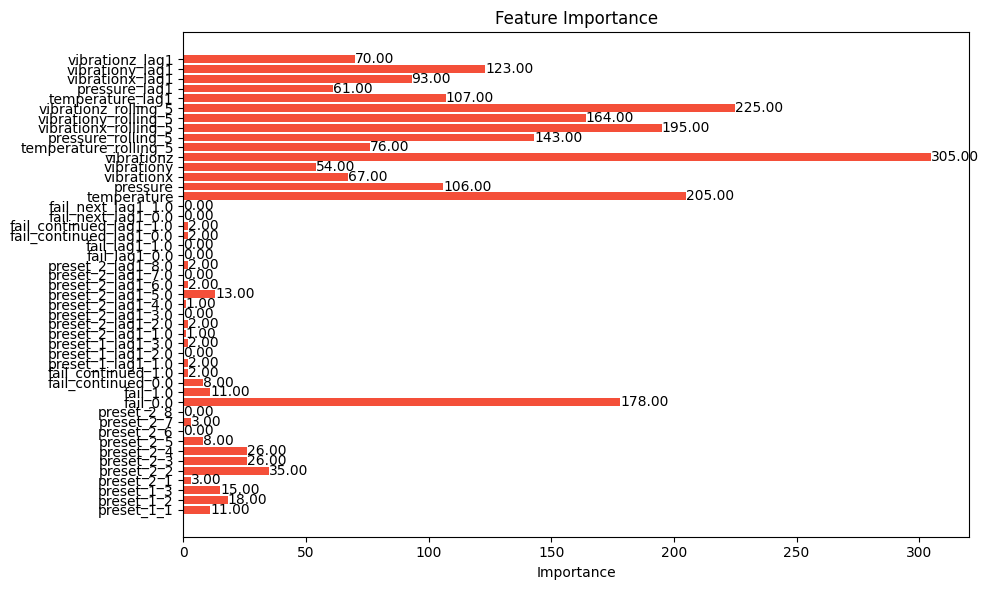

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


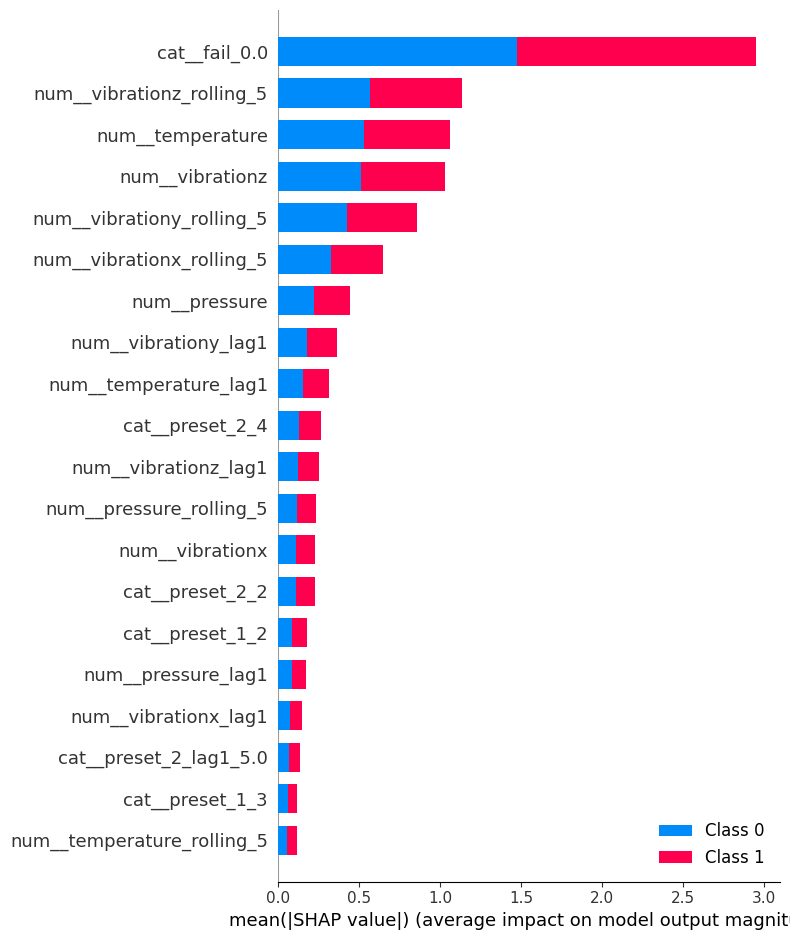

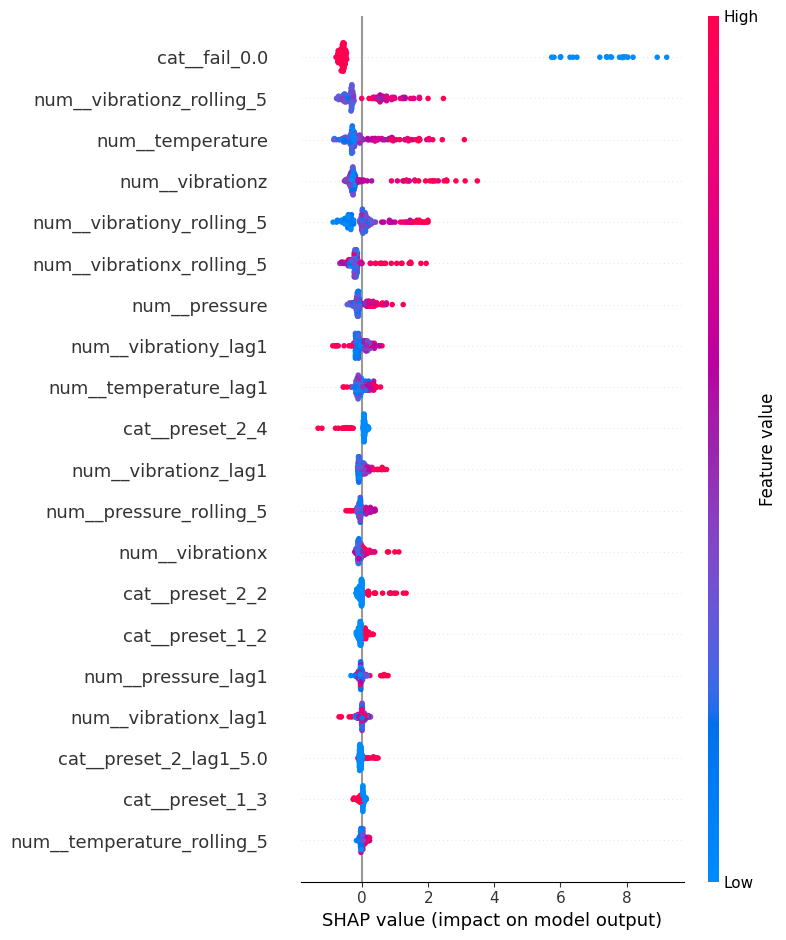

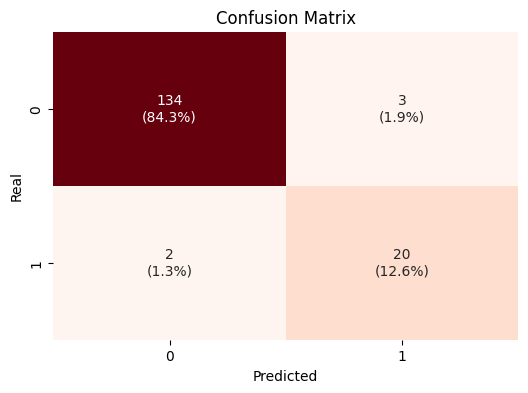

In [ ]:
evaluator = ModelEvaluator(y_pred,y_pred_proba,y_test,X_test,random_search,times_based_categorical_cols,times_based_numerical_cols)
evaluator.evaluate()